# Проверка логики алгоритмов в плагинах QGIS

In [1]:
import os

import osmnx as ox
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import tabulate
import contextily as ctx

# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\nContextily', ctx.__version__,
      )

ox.settings.default_access = ''

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
Contextily 1.6.2


In [2]:
DATA_NODE_FIELD     = 'node'
UNITS_NAME_FIELD    = 'name'
# Для графа:
EDGES_WEIGHT_FIELD  = 'travel_time'
## Для матрицы прибытия:
DATA_SAMPLE_SIZE    = None
DATA_CUTOFF_FIELD   = None
# TARGET_SET          = None

## Для ADD:
NAMES_PATTERN       = '{}'
START_NAMES_INDEX   = 1

In [ ]:
cutoff = 3
target_set = None
target_metric = 1  # 0 - по кол-ву подразделений, 1 - по ИП 
target_value = 90  # значение для остановки расчета

# 1. Загрузка данных

# Загрузка ГДС
from fire_units.metrics import CoverIndexBuildingADD
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, get_atm


G = ox.load_graphml('G:/QGIS/_genesis map/______________bbd352d3_4ebf_4a63_8261_ead198b399ea.ml')
G = ox.project_graph(G)
estimated_utm_crs = G.graph['crs']
print(f'Получен граф дорог с количеством узлов - {G.number_of_nodes()} и ребер {G.number_of_edges()}. СК: {estimated_utm_crs}')

# Воссоздание графа с расчетом времени проезда
gds_edges = gpd.read_file('G:/QGIS/_genesis map/data/sosnovoborsk.gpkg', layer='гдс')




# Загрузка зданий
target_layer_gdf = gpd.read_file('G:/QGIS/_genesis map/data/sosnovoborsk.gpkg', layer='здания')
target_layer_gdf.set_crs(crs=estimated_utm_crs, inplace=True)
target_layer_gdf = ox.projection.project_gdf(target_layer_gdf, to_crs=estimated_utm_crs)
centroids = target_layer_gdf.geometry.centroid
target_layer_gdf[DATA_NODE_FIELD] = ox.nearest_nodes(G, centroids.x, centroids.y)
print(f'Количество объектов в целевом слое - {len(target_layer_gdf)}')
if DATA_SAMPLE_SIZE:
    target_layer_gdf = target_layer_gdf.sample(DATA_SAMPLE_SIZE)
print(f'Из них в расчет взято - {len(target_layer_gdf)}')

# Загрузка существующих подразделений:
existed_units_dict = None




# 2. Расчет ADD
# Расчет матрицы прибытия
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 # data_sample_size  = DATA_SAMPLE_SIZE,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = cutoff,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )

# 3. Сборка решения
# ================================================================================================
## Выбор метрики
metric_func  = CoverIndexBuildingADD(target_layer_gdf, ip_val=cutoff)

## Функция обратного вызова при расчете подразделений
def after_mclp_function(best_metric, dynamic_nodes, **kwargs):
    metric = round(best_metric, 2)
    print(f'Подразделений: {len(dynamic_nodes)}, Метрика: {metric}')

## Функция остановки
def stop_case (value, dynamic_nodes, **kwargs):
    if target_metric == 0:
        return len(dynamic_nodes) >= target_value
    elif target_metric == 1:
        return value >= target_value


## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = FirstArrivalUnitState(),
    matrix              = matrix,
    metric_function     = metric_func,
    ip_val              = cutoff,
    stop_case_function  = stop_case,
    names_pattern       = NAMES_PATTERN,
    start_names_index   = START_NAMES_INDEX,
    after_mclp_function = after_mclp_function,
)

# 4. Расчет
# ================================================================================================
best_nodes, best_metric = add(
    env           = G,
    dynamic_nodes = None,
    static_nodes  = existed_units_dict,
    # area          = points_mask,
)







Получен граф дорог с количеством узлов - 3344 и ребер 13863. СК: EPSG:32646
Количество объектов в целевом слое - 603
Из них в расчет взято - 603
|########################################| 100.0%
Подразделений: 1, Метрика: 100.0


In [14]:
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 # data_sample_size  = DATA_SAMPLE_SIZE,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = 10,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )
matrix

|########################################| 100.0%


,341,340,64,63,62,2034,61,2828,60,2829,59,58
0,1,2,3,4,5,6,7,7,8,8,9,10
1,1,2,3,4,5,6,7,7,8,8,9,10
2,1,2,3,4,5,6,7,7,8,8,9,10
3,1,2,3,4,5,6,7,7,8,8,9,10
4,1,2,3,4,5,6,7,7,8,8,9,10
...,...,...,...,...,...,...,...,...,...,...,...,...
598,1,2,3,4,5,6,7,7,8,8,9,10
599,1,2,3,4,5,6,7,7,8,8,9,10
600,1,2,3,4,5,6,7,7,8,8,9,10
601,1,2,3,4,5,6,7,7,8,8,9,10


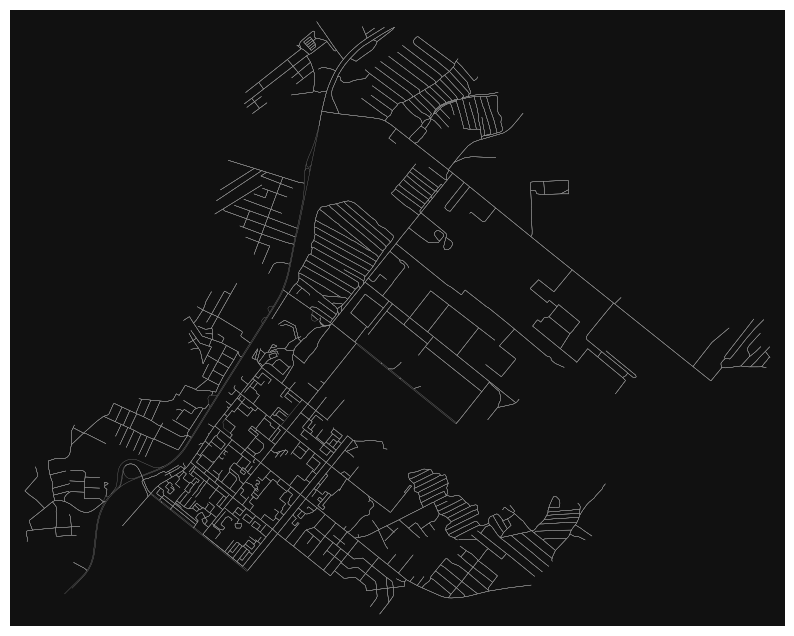

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [15]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, figsize=(10, 10))

In [17]:
times, _ = FirstArrivalUnitState()(G, [10])
times

10        1.0
11        2.0
9         2.0
12        3.0
8         3.0
        ...  
1872    136.0
1893    137.0
1903    138.0
1906    139.0
1917    140.0
Name: times, Length: 3293, dtype: float64

In [18]:
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes['arrival_time'] = times
g_nodes

,x,y,geometry,arrival_time
osmid,,,,
0,522170.510313,6.224067e+06,POINT (522170.51 6224067.182),11.0
1,521988.828514,6.223955e+06,POINT (521988.829 6223954.565),10.0
2,521913.372686,6.223901e+06,POINT (521913.373 6223900.597),9.0
1481,521973.563346,6.223993e+06,POINT (521973.563 6223992.986),11.0
3,521853.869548,6.223851e+06,POINT (521853.87 6223850.697),8.0
...,...,...,...,...
3324,519659.202026,6.219332e+06,POINT (519659.202 6219331.853),91.0
3325,519634.734679,6.219321e+06,POINT (519634.735 6219321.089),90.0
3326,519628.470486,6.219305e+06,POINT (519628.47 6219305.412),89.0


<Axes: >

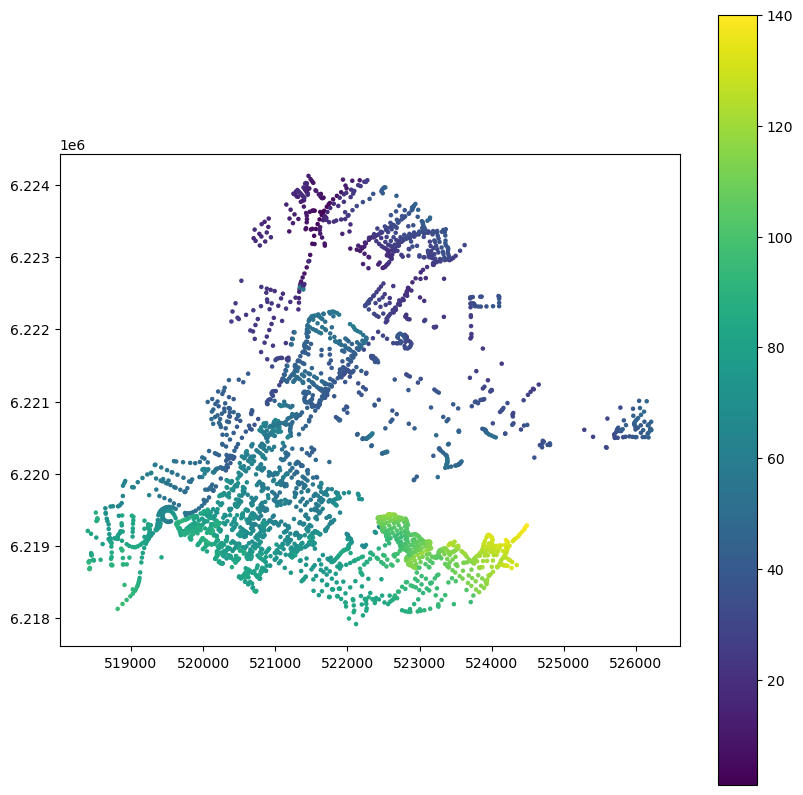

In [19]:
g_nodes.plot(column='arrival_time', figsize=(10, 10), markersize=5, legend=True)

In [20]:
ox.graph_to_gdfs(G, nodes=False)

highway  oneway lanes  reversed      length  \
u    v    key                                                  
0    1    0    secondary   False     2     False  213.754270   
          1    secondary   False     2     False  213.754270   
1    0    0    secondary   False     2     False  213.754270   
          1    secondary   False     2     False  213.754270   
     2    0    secondary   False     2     False   92.768940   
...                  ...     ...   ...       ...         ...   
3327 3326 1      service   False   NaN     False   14.410907   
     3328 0      service   False   NaN     False   36.478469   
          1      service   False   NaN     False   36.478469   
3336 3337 0      service   False   NaN     False   15.678278   
          1      service   False   NaN     False   15.678278   

                                                        geometry  
u    v    key                                                     
0    1    0    LINESTRING (522170.51 6224067.182, 521988.829 ...  
          1    LINESTRING (522170.51 6224067.182, 521988.829 ...  
1    0    0    LINESTRING (521988.829 6223954.565, 522170.51 ...  
          1    LINESTRING (521988.829 6223954.565, 522170.51 ...  
     2    0    LINESTRING (521988.829 6223954.565, 521913.373...  
...                                                          ...  
3327 3326 1    LINESTRING (519632.035 6219291.448, 519628.47 ...  
     3328 0    LINESTRING (519632.035 6219291.448, 519648.531...  
          1    LINESTRING (519632.035 6219291.448, 519648.531...  
3336 3337 0    LINESTRING (520013.572 6219479.529, 520002.201...  
          1    LINESTRING (520013.572 6219479.529, 520002.201...  

[13863 rows x 6 columns]